In [50]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

from metpy.calc import wind_speed
from metpy.calc import wind_direction 
from metpy.units import units

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'font.size' : 18})

# About
__Author:__ Pat McCornack  
__Date:__ 04/11/25  
__Purpose:__ Uses extracted netcdfs for standard meteorological variables and Chris Still met station data to evaluate WRF's performance.  

# Load/Process Data

In [51]:
root_dir = Path().resolve().parents[0]
met_df_fpath = root_dir /  'data' / 'weather-station' / 'combined-sites.csv'
met_coords_fpath = root_dir / 'data' / 'weather-station' / 'sci-stations.csv'
clean_outfpath = root_dir /  'data' / 'weather-station' / 'combined-sites-clean.csv'

met_coords = pd.read_csv(met_coords_fpath)  # Info about the weather stations
met_coords = met_coords.loc[~met_coords['station'].isin(['eend', 'eenc', 'crat', 'pozo-smo2', 'pozo-smo1'])]  # Drop irrelevant sites

## Process Weather Station Data

In [52]:
# Set up met_df
met_df = pd.read_csv(met_df_fpath, index_col=0)
met_df['time (PST)'] = pd.to_datetime(met_df['time (PST)'])

met_df = met_df[['site', 'time (PST)', 'air temperature (C)', 'relative humidity (%)', 'wind speed (m/s)', 'wind direction (deg)', 'fog tips', 'rain (mm)']]
met_df = met_df.loc[~met_df['site'].isin(['eend', 'eenc', 'crat', 'pozo-smo2', 'pozo-smo1'])]  # Drop irrelevant sites

met_df.describe()


,time (PST),air temperature (C),relative humidity (%),wind speed (m/s),wind direction (deg),fog tips,rain (mm)
count,622499,603912.000000,613093.000000,582516.000000,574226.000000,622499.000000,622484.000000
mean,2006-11-14 01:20:39.554279936,14.174732,69.607999,1.679329,225.004033,0.183210,0.013066
min,2003-12-19 16:00:00,0.850000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2005-05-06 22:15:00,10.780000,52.110000,0.540000,122.300000,0.000000,0.000000
50%,2006-05-21 02:00:00,13.150000,80.800000,1.432000,286.399990,0.000000,0.000000
75%,2008-05-15 03:07:30,16.799999,95.750000,2.555000,317.800000,0.000000,0.000000
max,2011-10-01 23:00:00,111.400000,100.000000,16.120000,677.000000,663.000000,35.408997
std,NaN,4.917584,31.357300,1.431682,112.578061,1.662642,0.175437


__Maximum outliers__  
Air temperatures maximum is 111.4 - which is impossible. There's several rows with this value, and these are all set to NAN.  
Similarly, there's a recorded wind direction value of over 360, this is also set to nan

In [53]:
# Handle outliers

# Air temperature over 50C is unlikely
met_df.loc[met_df['air temperature (C)'] > 50] # Values are all 111.4 -> set to NaN
met_df.loc[met_df['air temperature (C)'] > 50, 'air temperature (C)'] = np.nan

# Can't have wind direction over 360
met_df.loc[met_df['wind direction (deg)'] > 360, 'wind direction (deg)'] = np.nan

__Air Temperature Minimum Outliers__  
Ther's a bunch of air temperature observations from June 17, 2011 for Sauces Canyon. The low recorded by the RAWS stations for this day was 50*F, so these are probably bad. 

In [54]:
met_df.loc[(met_df['air temperature (C)'] < 2) & (met_df['time (PST)'].dt.month == 6), 'air temperature (C)'] = np.nan

In [55]:
met_df.describe()

,time (PST),air temperature (C),relative humidity (%),wind speed (m/s),wind direction (deg),fog tips,rain (mm)
count,622499,603889.000000,613093.000000,582516.000000,574225.000000,622499.000000,622484.000000
mean,2006-11-14 01:20:39.554279936,14.174674,69.607999,1.679329,225.003246,0.183210,0.013066
min,2003-12-19 16:00:00,1.847000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2005-05-06 22:15:00,10.780000,52.110000,0.540000,122.300000,0.000000,0.000000
50%,2006-05-21 02:00:00,13.150000,80.800000,1.432000,286.399990,0.000000,0.000000
75%,2008-05-15 03:07:30,16.799999,95.750000,2.555000,317.800000,0.000000,0.000000
max,2011-10-01 23:00:00,40.670000,100.000000,16.120000,360.000000,663.000000,35.408997
std,NaN,4.912346,31.357300,1.431682,112.576579,1.662642,0.175437


In [56]:
# Set multiindex 
sites = met_df['site'].unique().tolist()
met_df = met_df.set_index(['site', 'time (PST)'])

# QC

## Relative Humidity  
Look at relative humidity plots to see when/if sensors failed.   

__Observations__: 
- WRDG: Dropped all zeros in WRDG set - these also were all zeros for the other variables, so the whole row would get dropped. 
- SAUC: Max values started steadily declining in 2008, then the sensor failed late 2009. It looks like it was recalibrated after 2010 and redeployed in late 2011. Values from 2009-10-01 to 2011-01-01 were set to nan. 
- CRAK: From August 2005 onward the values start declining then get erratic. Looks like it was recalibrated at the end of the dataset. Removed observations after 2005-07-31. 
- ERDG: Looks erratic from 2006 onward, removed these data. 


All other sites look fine.

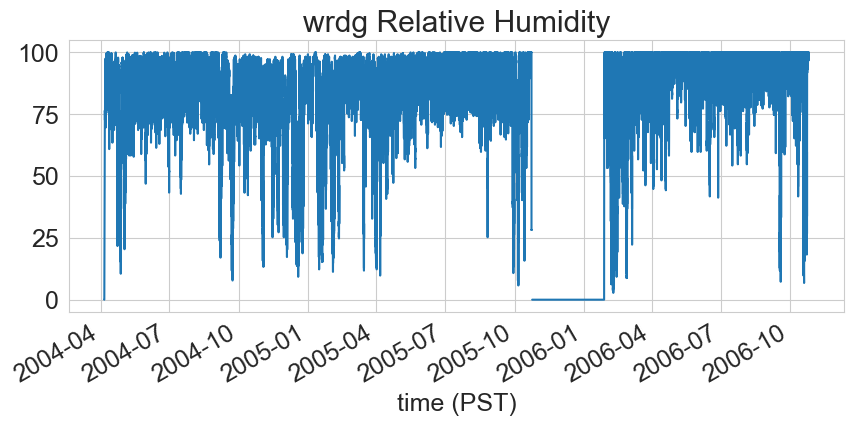

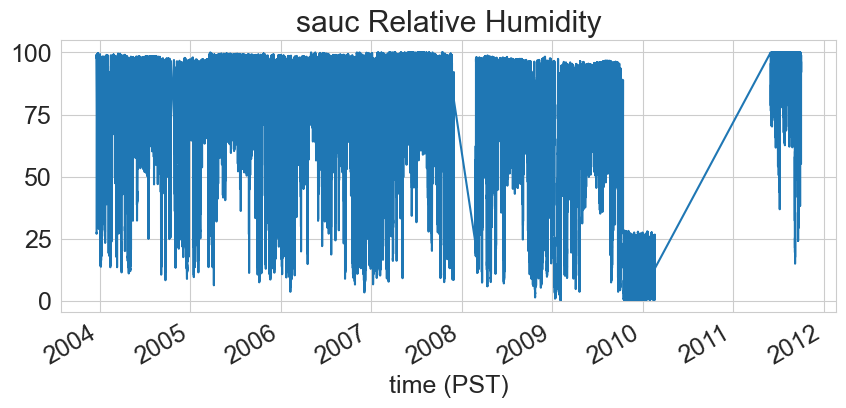

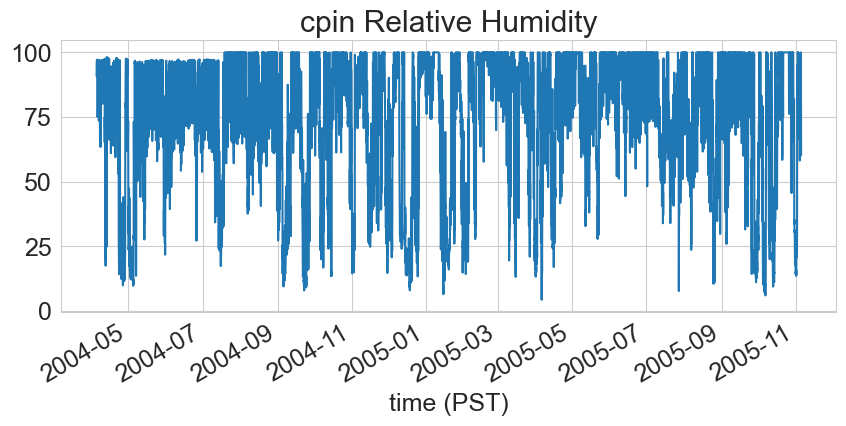

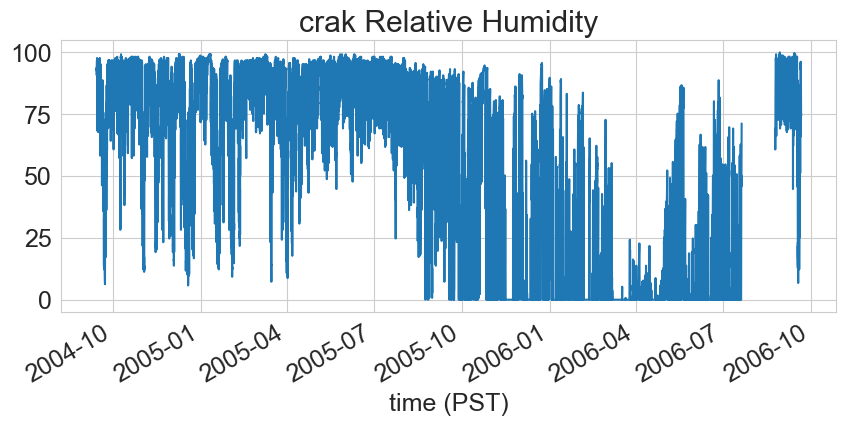

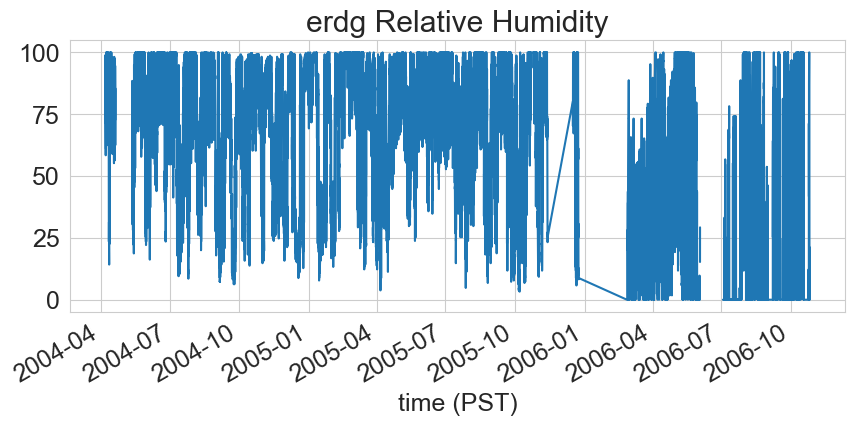

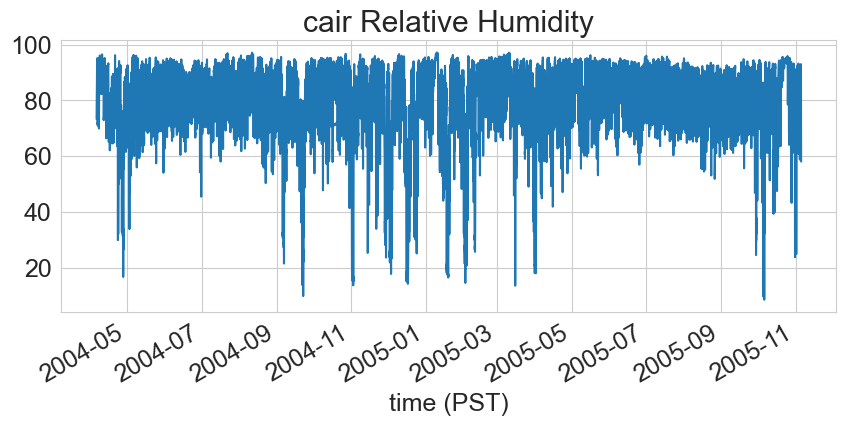

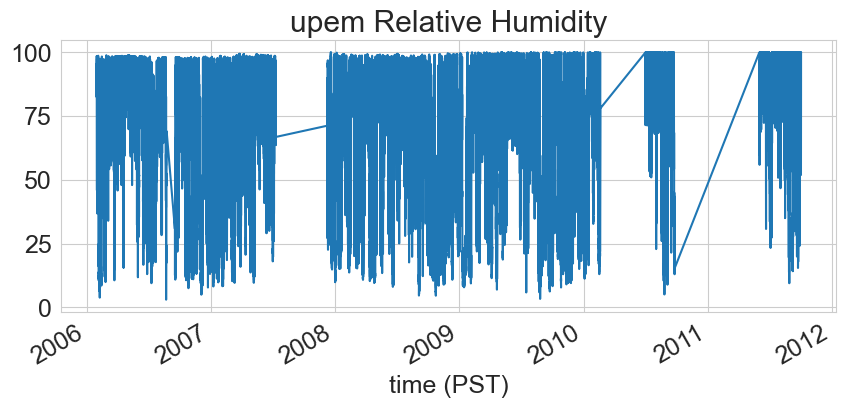

In [57]:
for i, site in enumerate(sites):
    site_df = met_df.loc[site]

    fig, ax = plt.subplots(figsize=(10,4))
    site_df['relative humidity (%)'].plot(ax=ax)
    ax.set(title=f'{site} Relative Humidity')
    plt.show()


### Handling bad RH values

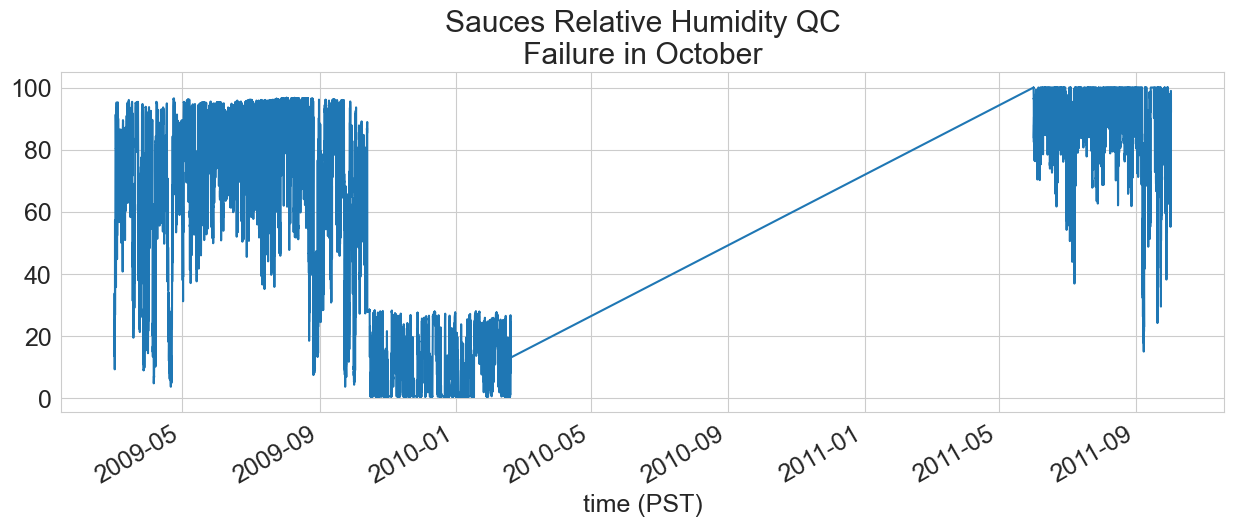

In [58]:
# SAUC: - Remove data 2009-10-01 to 2011
sauc_df = met_df.loc['sauc']
fig, ax = plt.subplots(figsize=(15,5))
sauc_df.loc['2009-03-01':'2012-04-01', 'relative humidity (%)'].plot(ax=ax)
ax.set(title='Sauces Relative Humidity QC\nFailure in October')
plt.show()

sauc_mask = ((met_df.index.get_level_values('site') == 'sauc') &
             (met_df.index.get_level_values('time (PST)') >= pd.to_datetime('2009-10-01')) &
             (met_df.index.get_level_values('time (PST)') < pd.to_datetime('2011-01-01')))
met_df.loc[sauc_mask, 'relative humidity (%)'] = np.nan

In [59]:
# WRDG - Rows with 0 in RH have all zeros, replace entire rows with NaNs
wrdg_mask = ((met_df.index.get_level_values('site') == 'wrdg') & (met_df['relative humidity (%)'] == 0))
met_df.loc[wrdg_mask] = np.nan

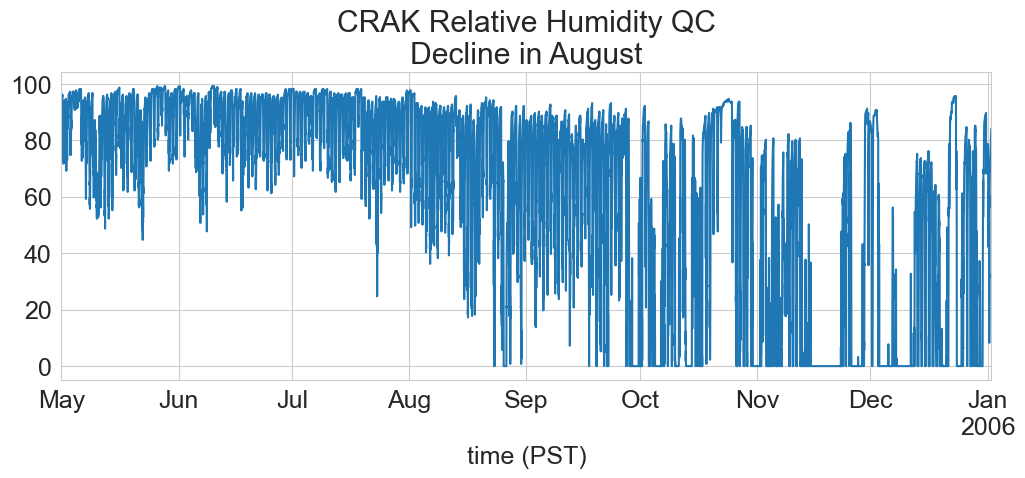

In [60]:
# CRAK - Check when the sensor goes bad and remove that section
crak_df = met_df.loc['crak']
fig, ax = plt.subplots(figsize=(12,4))
crak_df.loc['2005-05-01':'2006-01-01']['relative humidity (%)'].plot(ax=ax)
ax.set(title='CRAK Relative Humidity QC\nDecline in August')
plt.show()

crak_mask = (met_df.index.get_level_values('site') == 'crak') & (met_df.index.get_level_values('time (PST)') >= pd.to_datetime('2005-08-01'))
met_df.loc[crak_mask, 'relative humidity (%)'] = np.nan  # Set bad timeframe to nan

In [61]:
# ERDG - Remove after 2006
erdg_mask = (met_df.index.get_level_values('site') == 'erdg') & (met_df.index.get_level_values('time (PST)') >= pd.to_datetime('2006-01-01'))
met_df.loc[erdg_mask, 'relative humidity (%)'] = np.nan

## Air Temperature
Check air temperature values to see when/if sensors failed.

__Observations__: For UPEM, after 2011 the values are very narrowly constrained. Air temperature data after 2011 was set to nan.

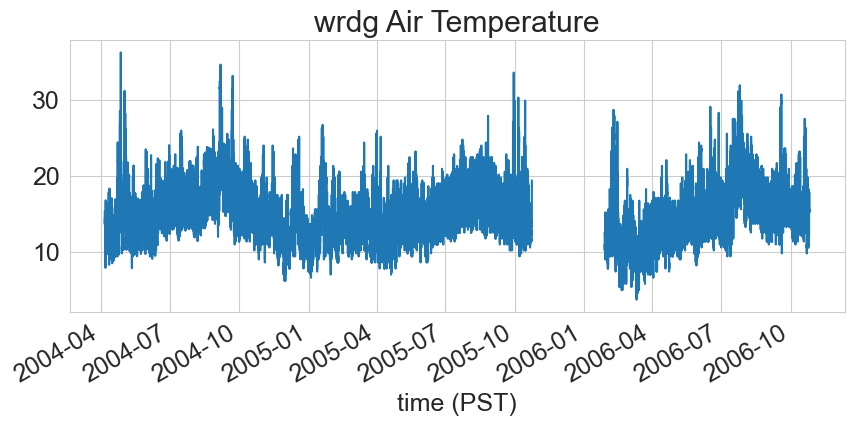

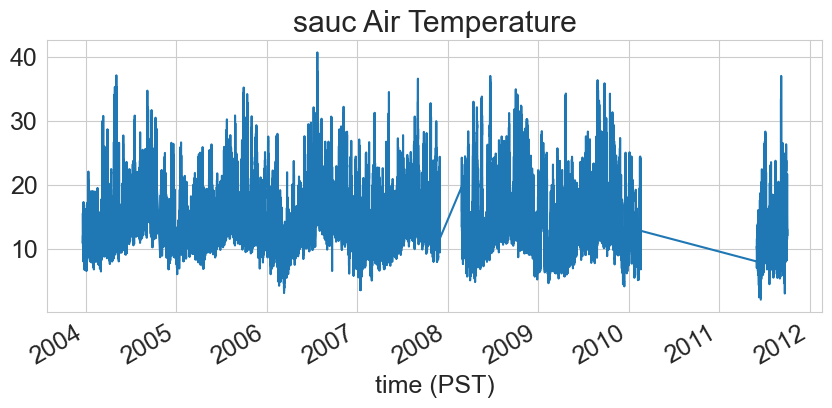

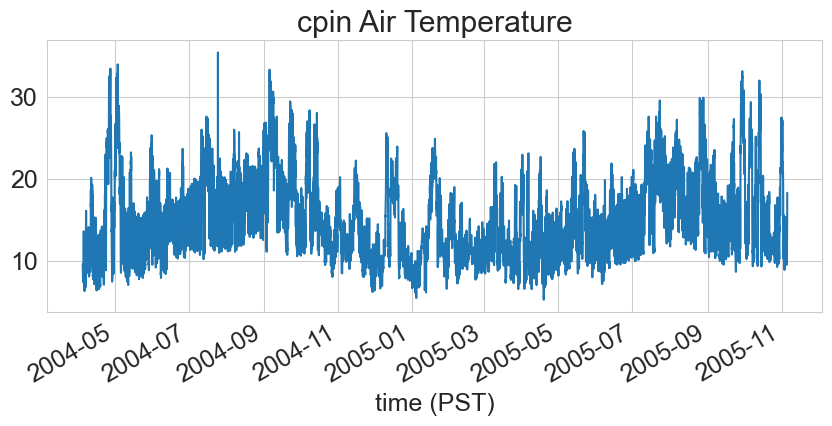

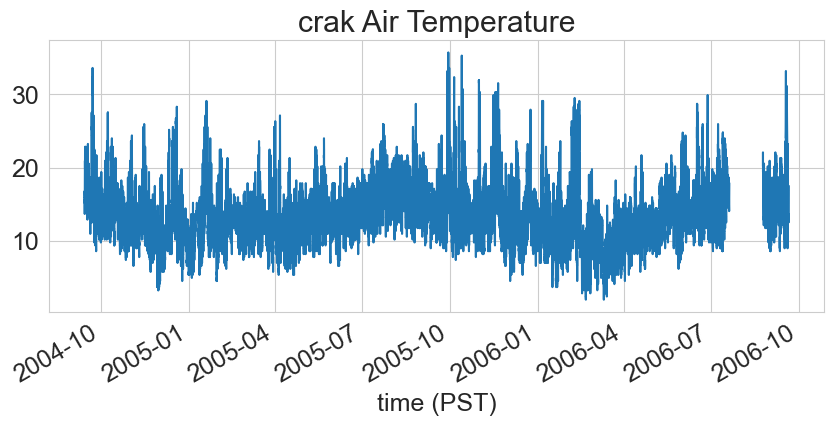

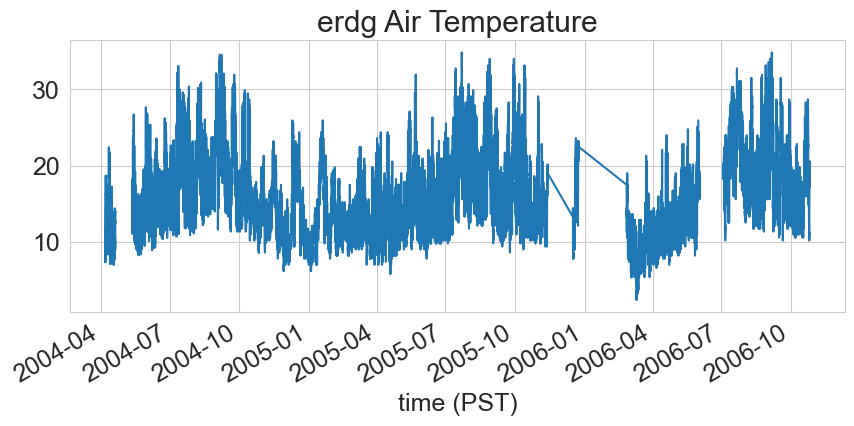

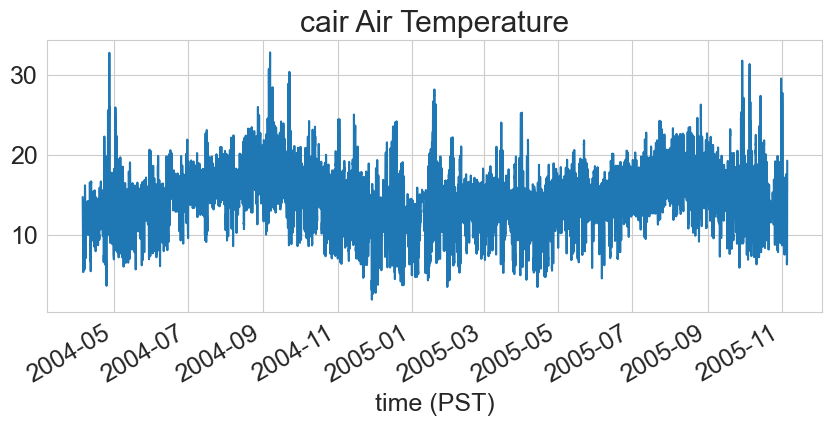

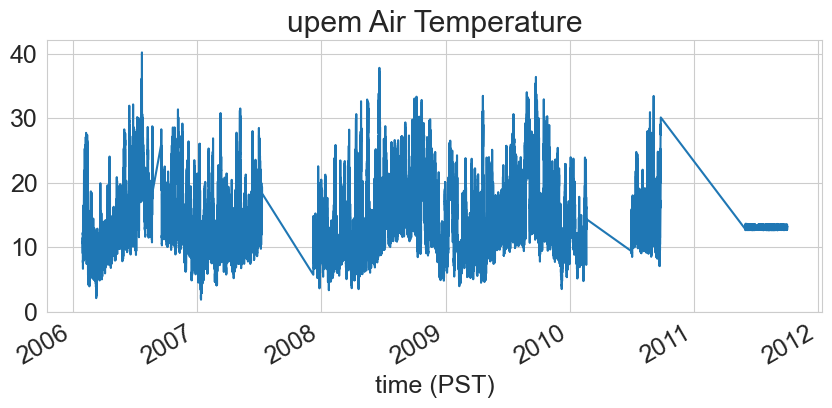

In [62]:
for i, site in enumerate(sites):
    site_df = met_df.loc[site]

    fig, ax = plt.subplots(figsize=(10,4))
    site_df['air temperature (C)'].plot(ax=ax)
    ax.set(title=f'{site} Air Temperature')
    plt.show()

### Handle bad air temperature values

In [63]:
# UPEM - set values afte 2011 to null
upem_mask = ((met_df.index.get_level_values('site') == 'upem') & (met_df.index.get_level_values('time (PST)') >= pd.to_datetime('2011-01-01')))
met_df.loc[upem_mask, 'air temperature (C)'] = np.nan

## Wind Speed
Check wind speed values to see when/if sensors failed. 

__Observations:__
- SAUC: Period around 2010 with consistently very low values. Values after 2009-11-01 were set to nan.

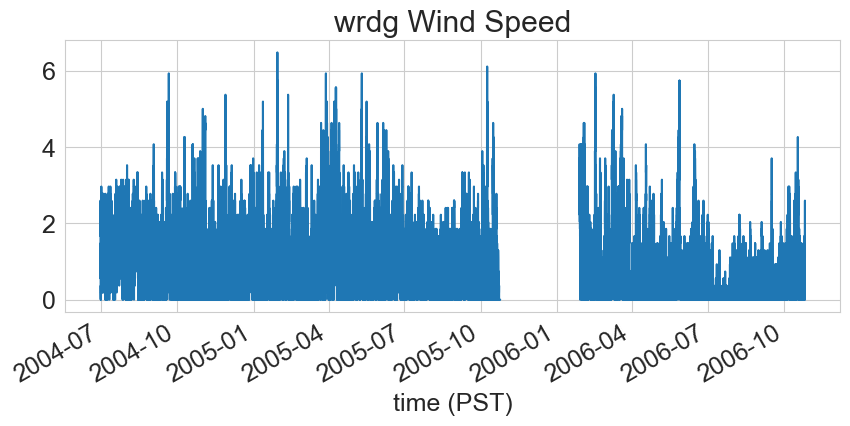

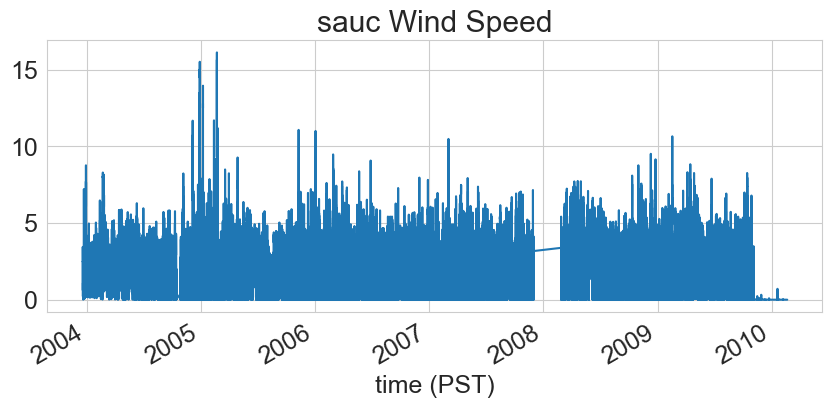

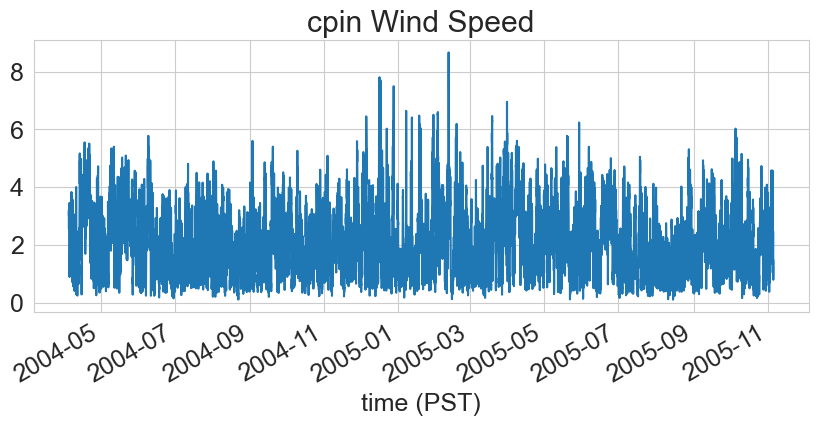

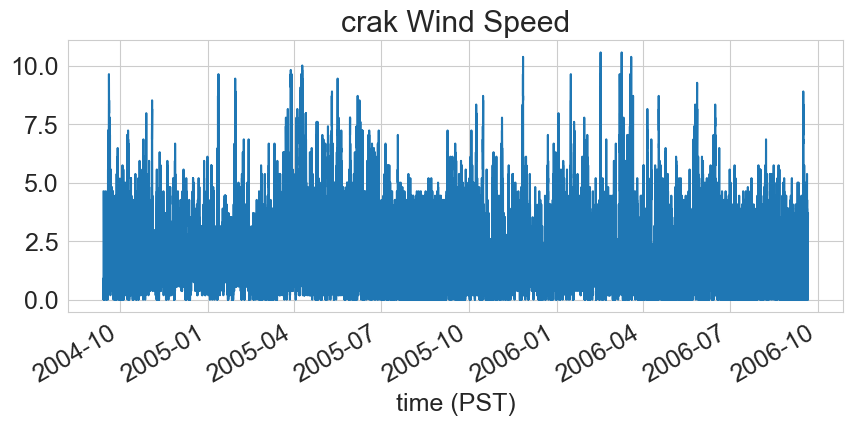

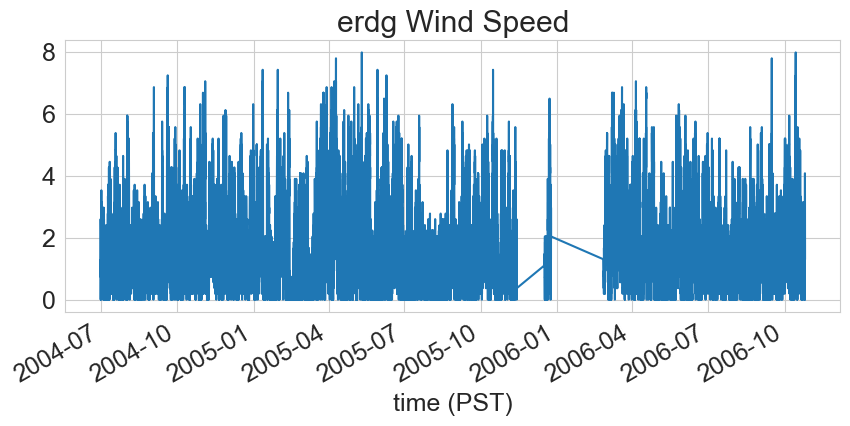

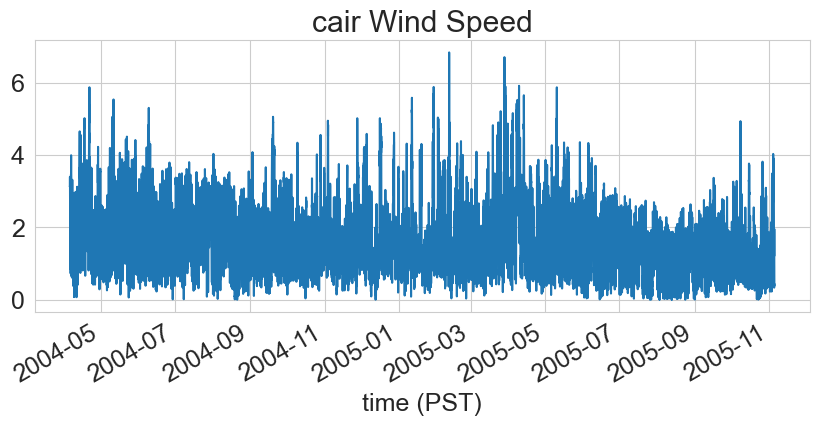

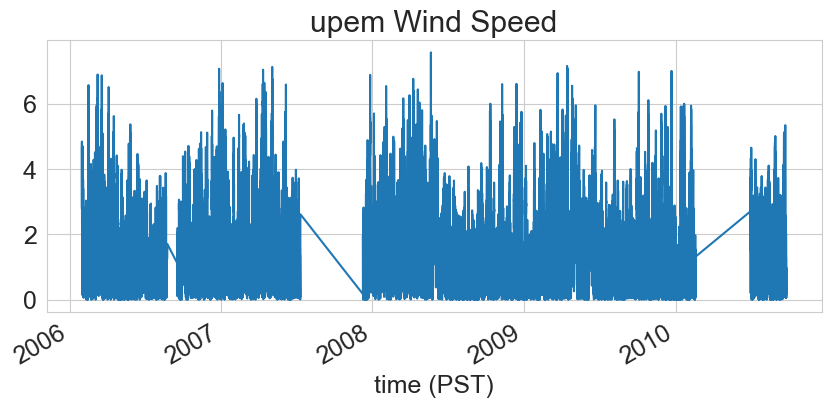

In [64]:
for i, site in enumerate(sites):
    site_df = met_df.loc[site]

    fig, ax = plt.subplots(figsize=(10,4))
    site_df['wind speed (m/s)'].plot(ax=ax)
    ax.set(title=f'{site} Wind Speed')
    plt.show()

### Handle bad wind speed values

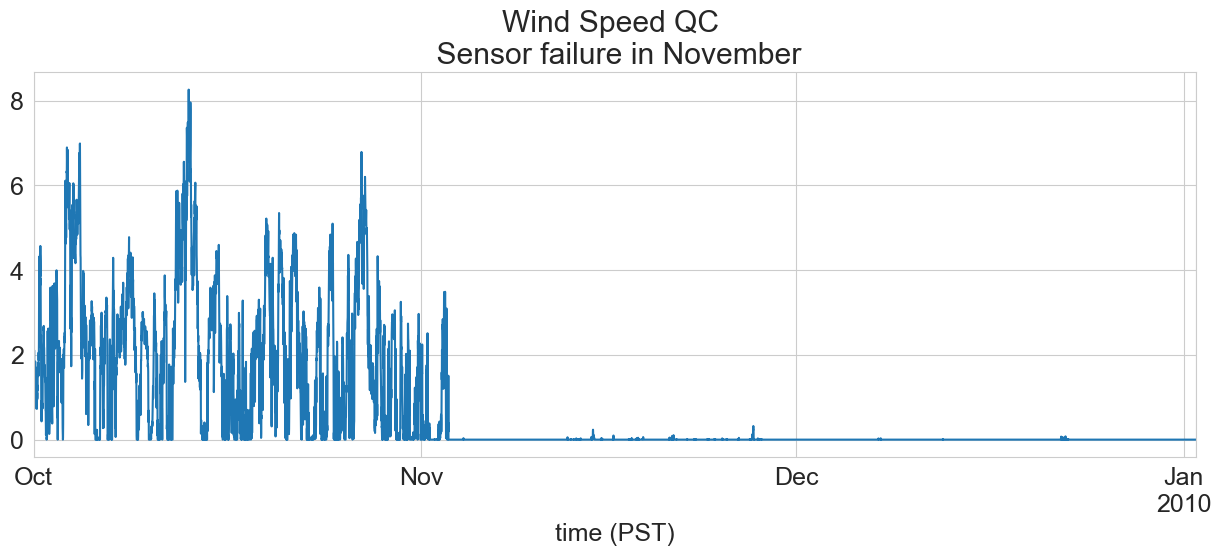

In [65]:
# SAUC - Sensor went bad beginning of november 2010
sauc_df = met_df.loc['sauc']
fig, ax = plt.subplots(figsize=(15,5))
sauc_df.loc['2009-10-01':'2010-01-01', 'wind speed (m/s)'].plot(ax=ax)
ax.set(title='Wind Speed QC \n Sensor failure in November')
plt.show()

sauc_mask = ((met_df.index.get_level_values('site') == 'sauc') & (met_df.index.get_level_values('time (PST)') >= pd.to_datetime('2009-11-01')))
met_df.loc[sauc_mask, 'wind speed (m/s)'] = np.nan

## Wind Direction
Check wind direction values to see when/if sensors failed.

__Observations:__
- SAUC: Sensor failure after 2009-11, the rest of the values were set to nan. 

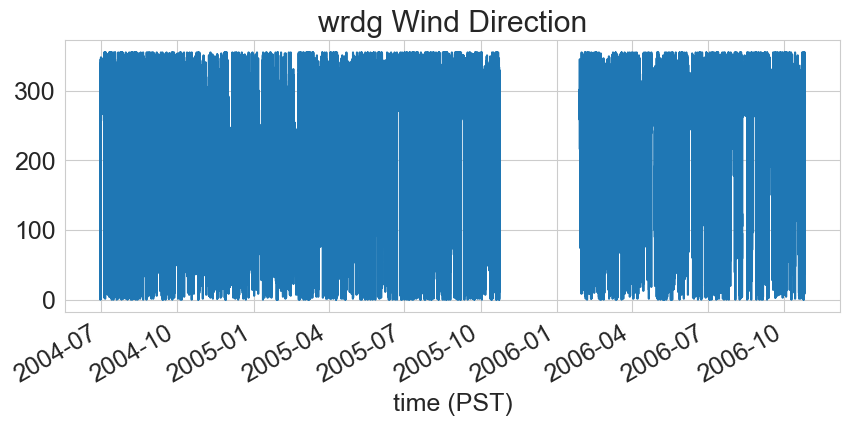

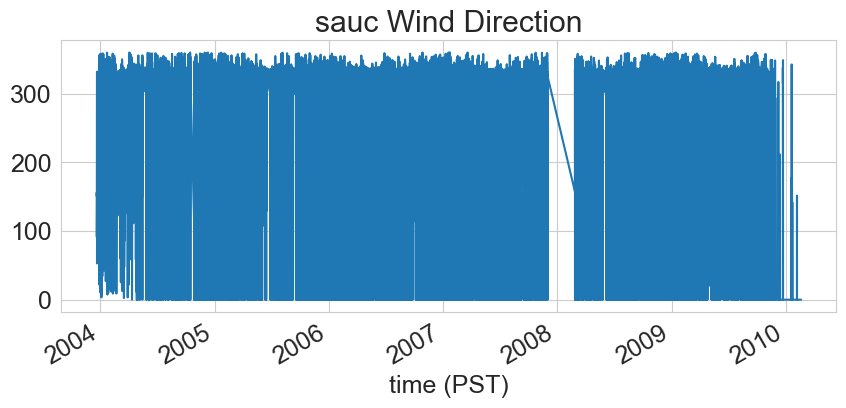

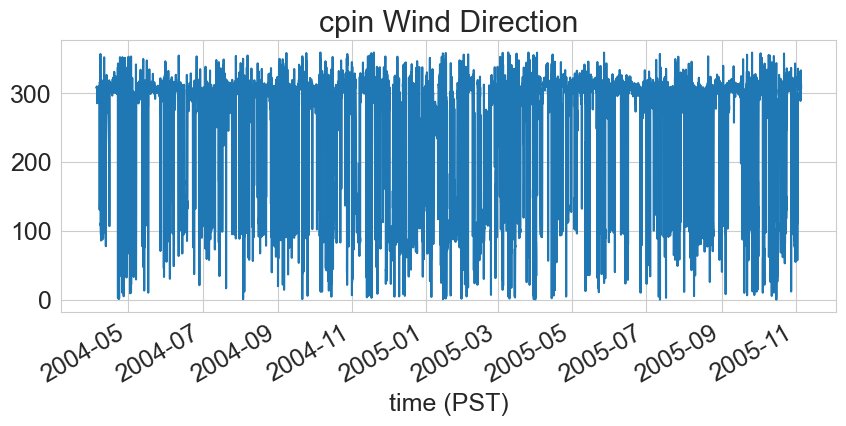

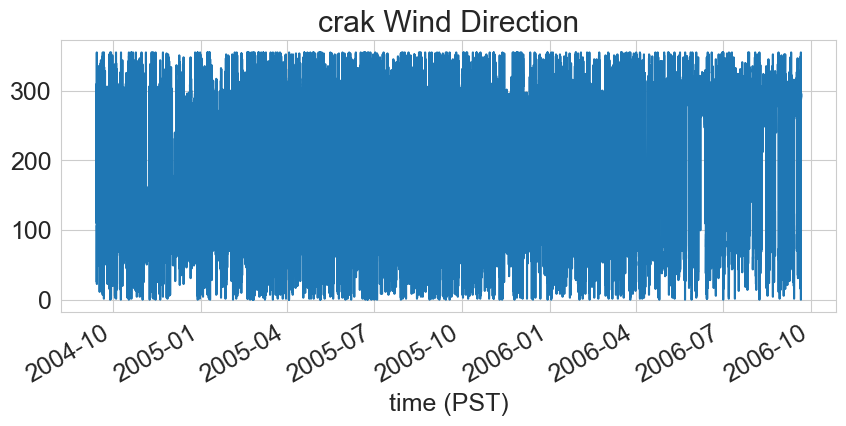

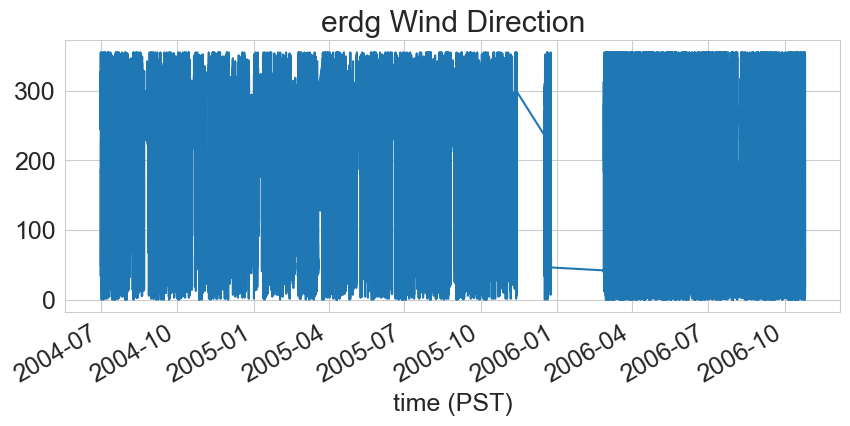

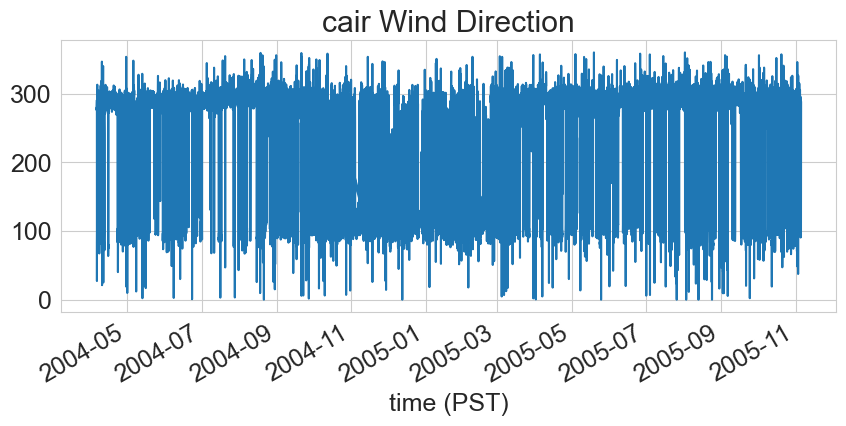

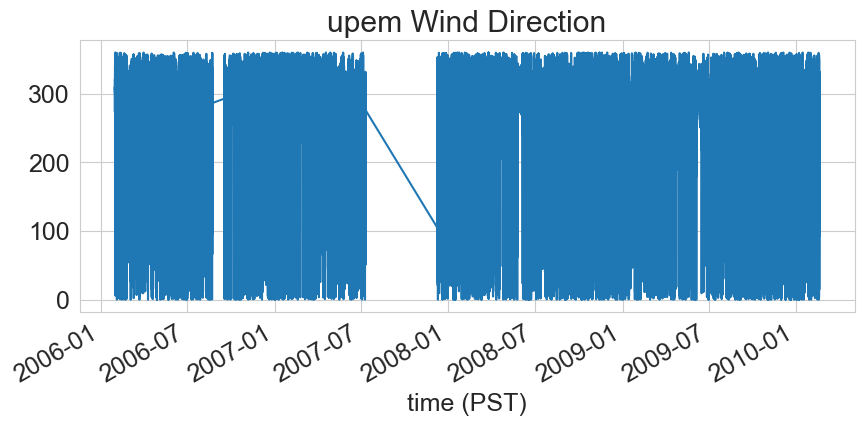

In [66]:
for i, site in enumerate(sites):
    site_df = met_df.loc[site]

    fig, ax = plt.subplots(figsize=(10,4))
    site_df['wind direction (deg)'].plot(ax=ax)
    ax.set(title=f'{site} Wind Direction')
    plt.show()

### Handle bad wind direction values

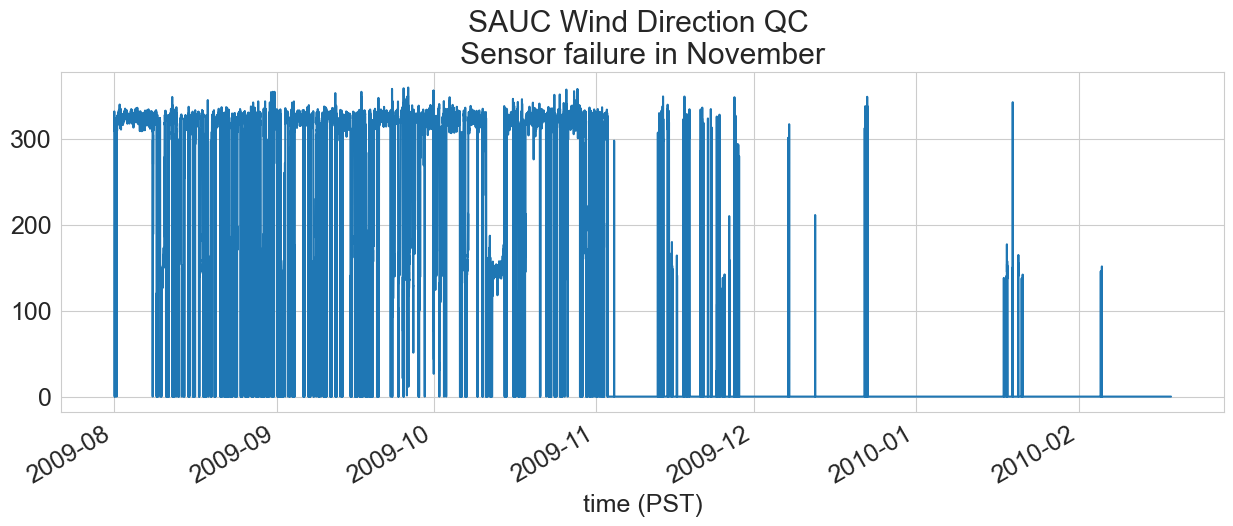

In [67]:
# SAUC
sauc_df = met_df.loc['sauc']
fig, ax = plt.subplots(figsize=(15,5))
sauc_df.loc['2009-08-01':, 'wind direction (deg)'].plot(ax=ax)
ax.set(title='SAUC Wind Direction QC \nSensor failure in November')
plt.show()

sauc_mask = ((met_df.index.get_level_values('site') == 'sauc') & (met_df.index.get_level_values('time (PST)') >= pd.to_datetime('2009-11-01')))
met_df.loc[sauc_mask, 'wind direction (deg)'] = np.nan

## Fog
Check fog data for when/if sensors failed. 

__Observations:__ 
- Most sites have gaps, but it's hard to tell if these are missing data, fogless periods, or something else. No action will be taken for this for now. 
- ERDG: Has some very high values that look like they were storm event bycatch based on the rain data. Given that these occurred outside the season of interest they were not changed.

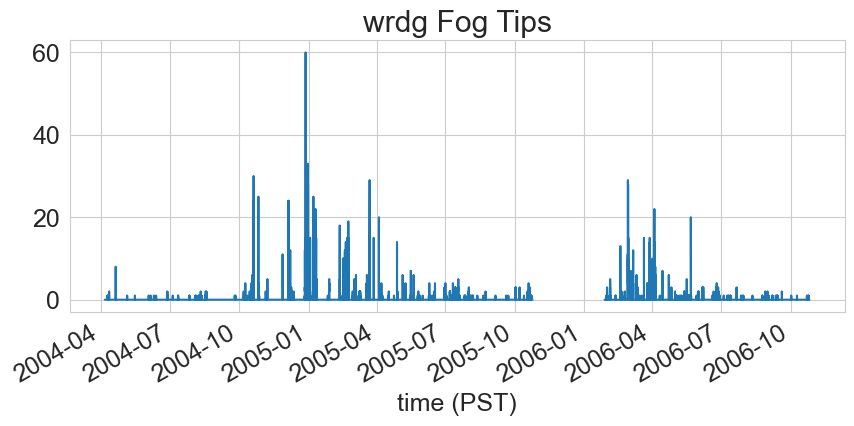

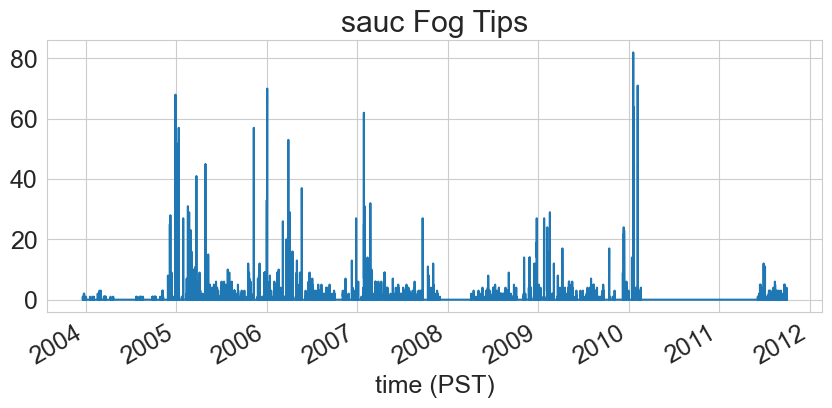

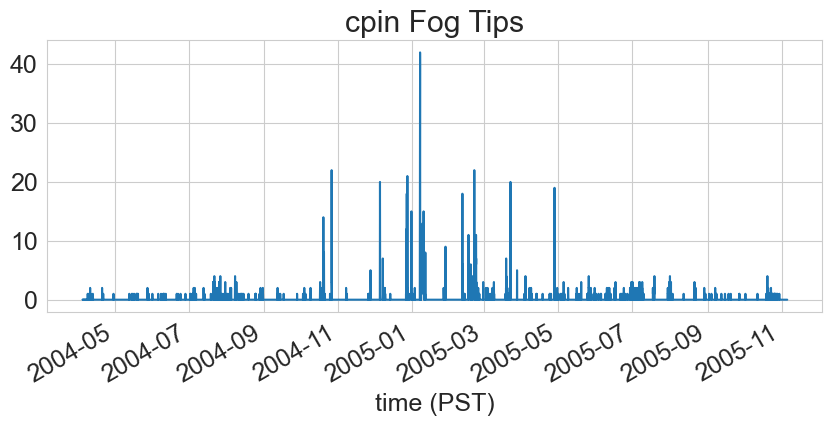

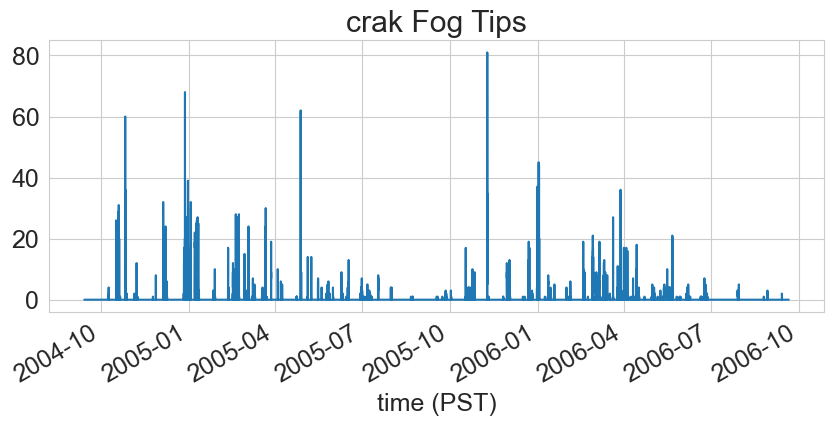

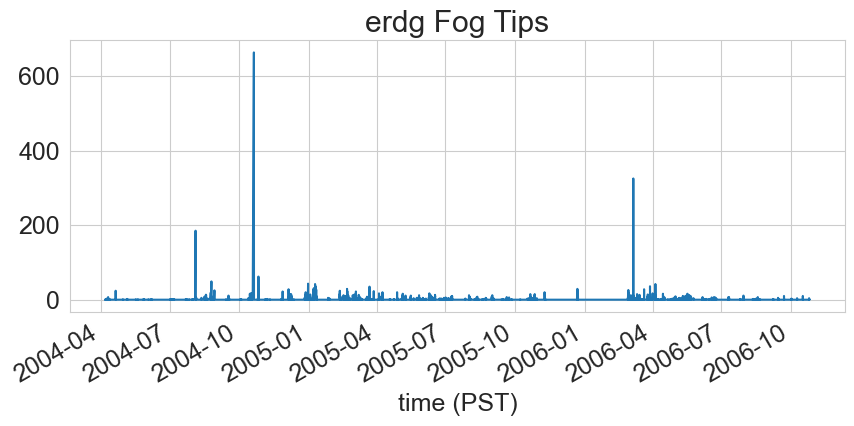

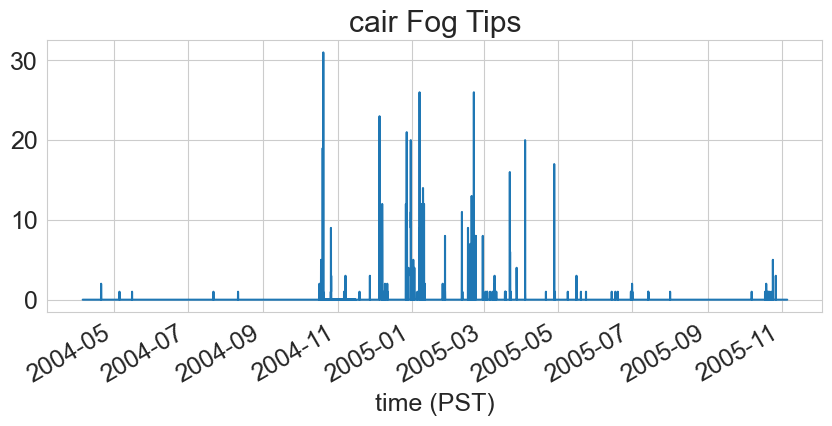

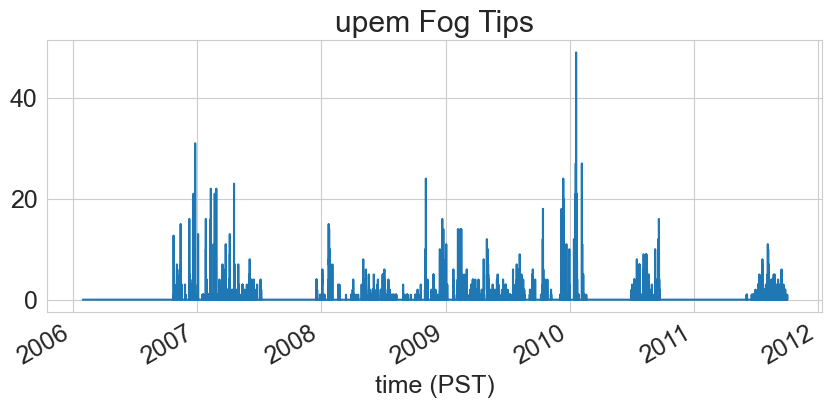

In [68]:
for i, site in enumerate(sites):
    site_df = met_df.loc[site]

    fig, ax = plt.subplots(figsize=(10,4))
    site_df['fog tips'].plot(ax=ax)
    ax.set(title=f'{site} Fog Tips')
    plt.show()

## Rain
Check rain values for when/if sensors went bad.

__Observations__:
- No obvious problems.

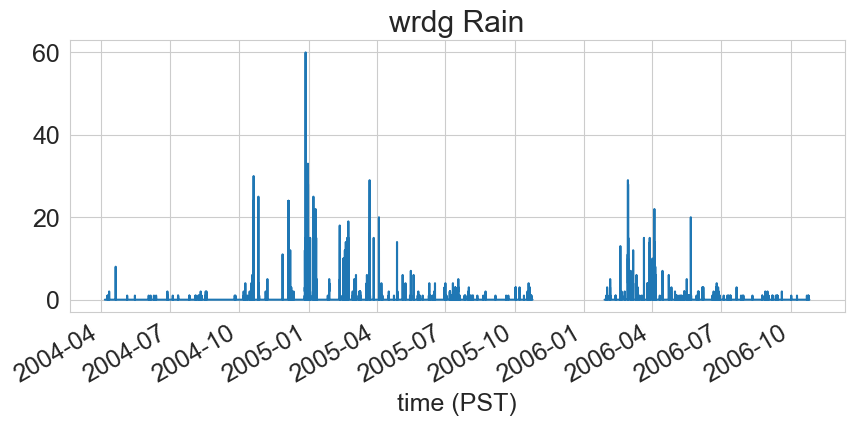

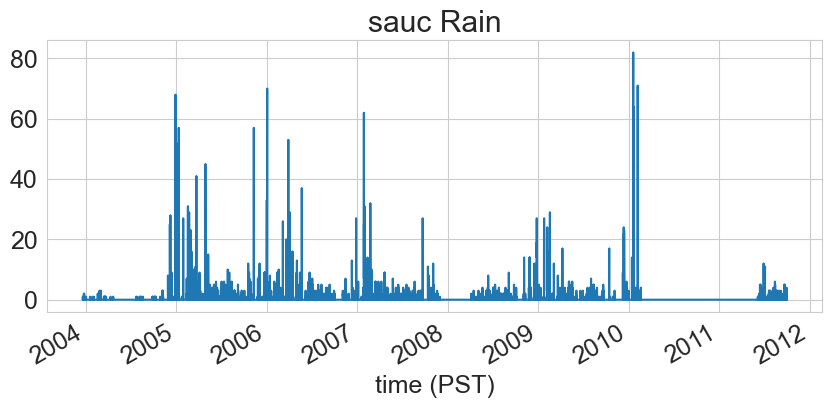

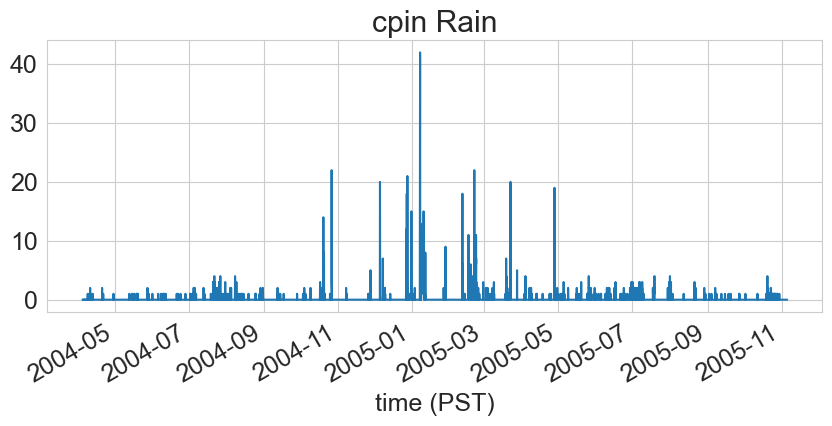

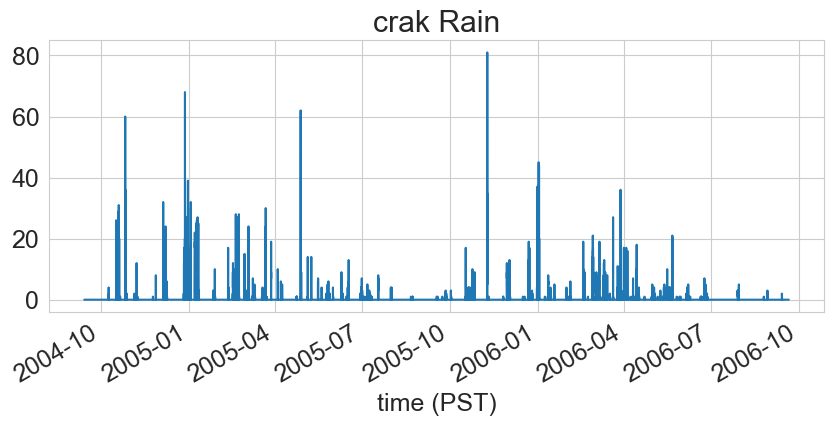

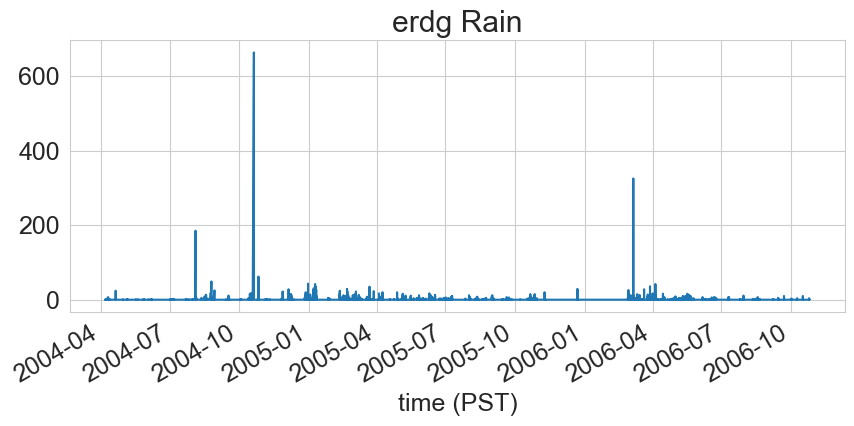

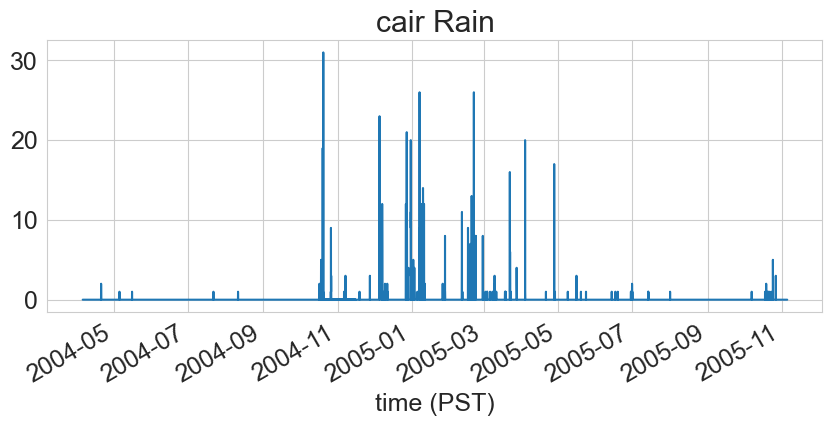

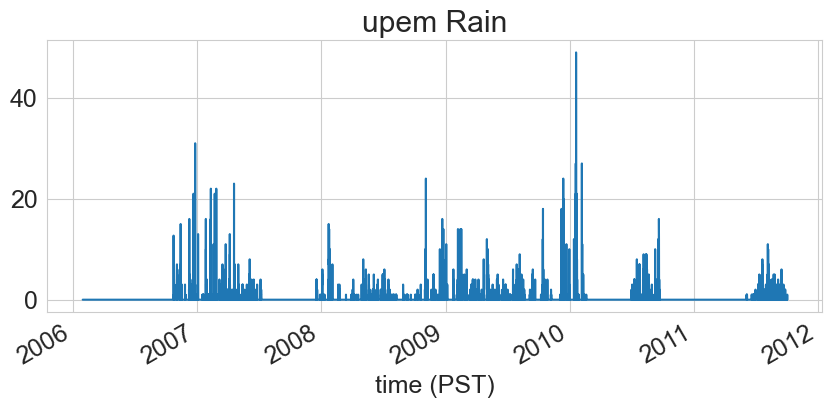

In [69]:
for i, site in enumerate(sites):
    site_df = met_df.loc[site]

    fig, ax = plt.subplots(figsize=(10,4))
    site_df['fog tips'].plot(ax=ax)
    ax.set(title=f'{site} Rain')
    plt.show()

## Subset to summer months
Given that May-Sept is the foggy season, and when fog is most ecologically relevant, subset the data to may-sept. This is done before checking for rain bycatch, because rain is rare during this time period which simplifies the analysis - we don't have to take care of cleaning up winter rain events. 

In [70]:
# Subset to summer months
summer_mask = met_df.index.get_level_values('time (PST)').month.isin([5,6,7,8,9])
met_df = met_df.loc[summer_mask]

## Check Rain/Fog Overlap
A known problem is that fog harps can get bycatch from rain, which looks like concurrent rain/fog tips. Below shows timesteps that had rain or fog values greater than 0. There are scattered incidents of concurrent tips, but there's no way to tell if this was bycatch or something like light drizzle that blurs the line between fog/rain. No action was taken. 

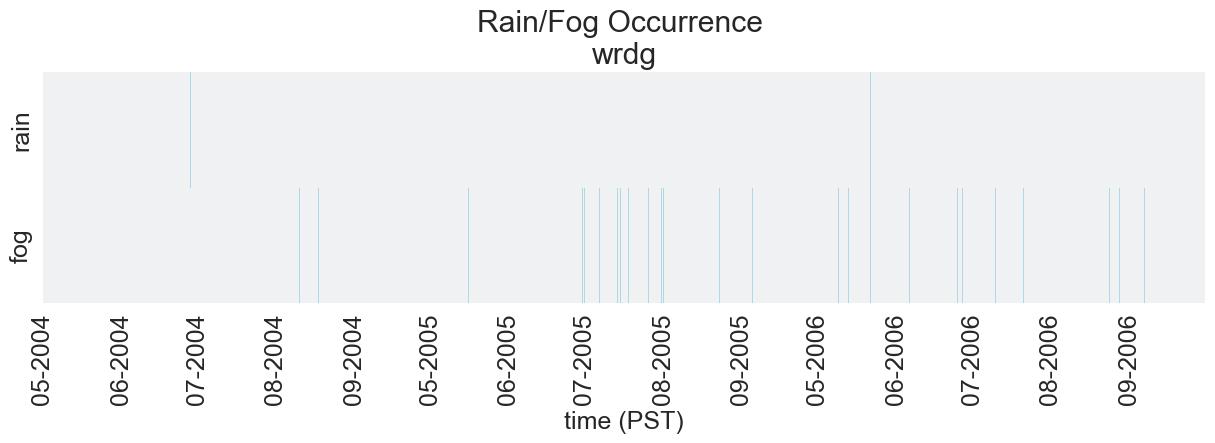

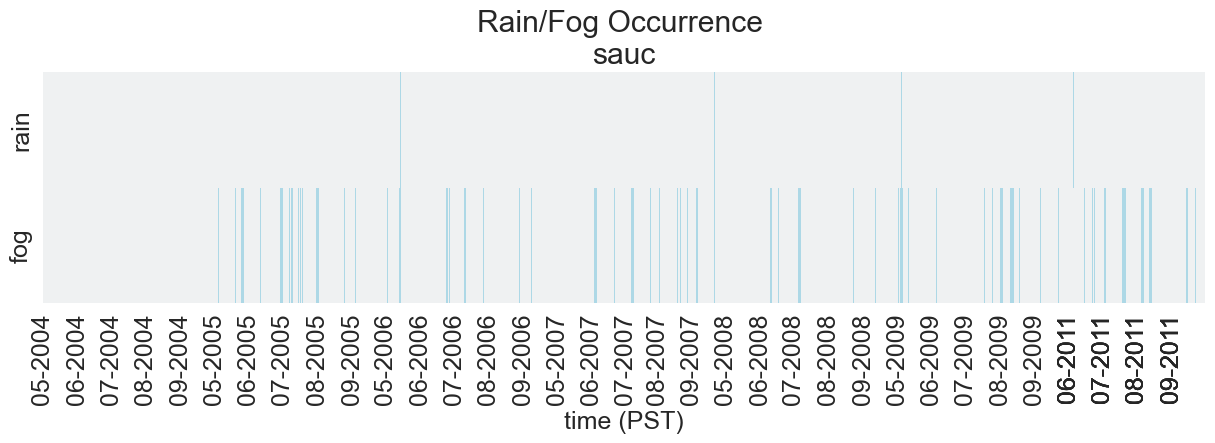

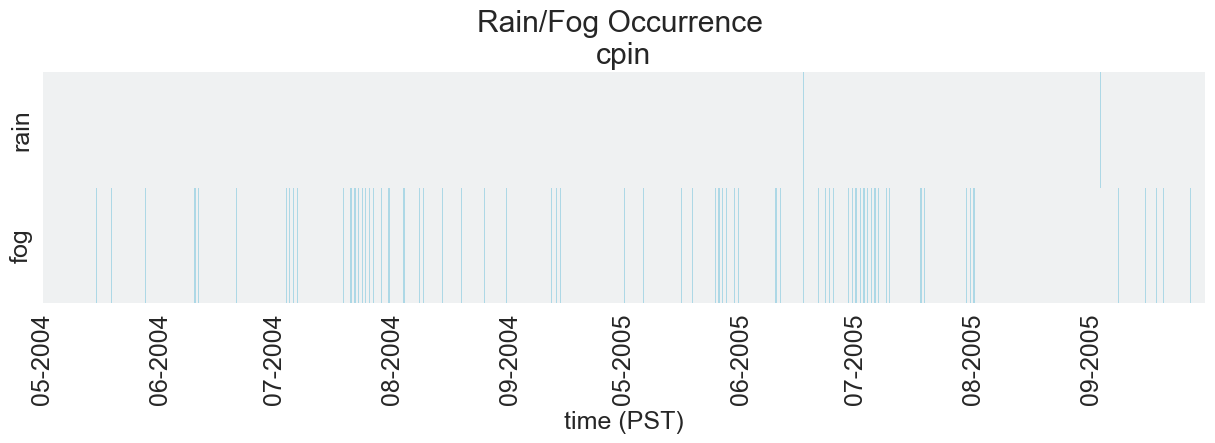

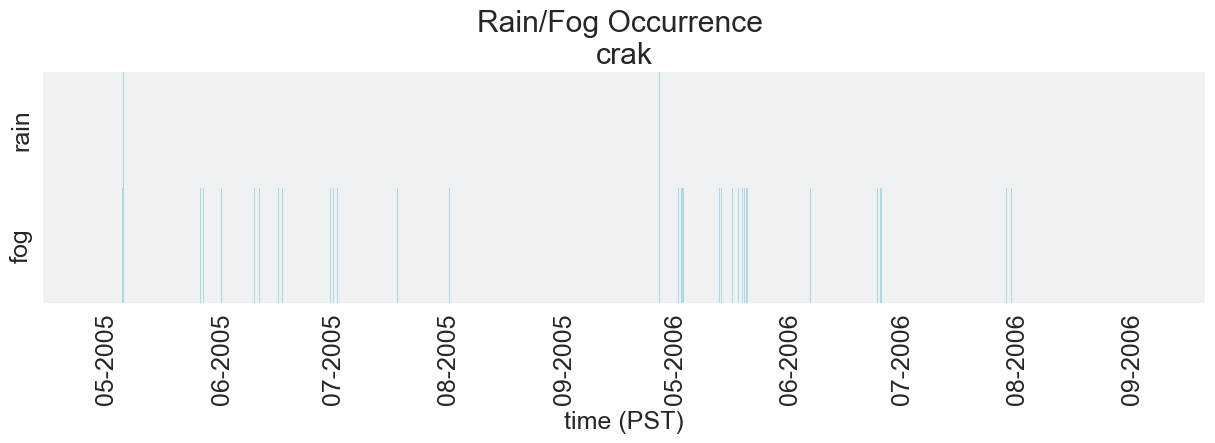

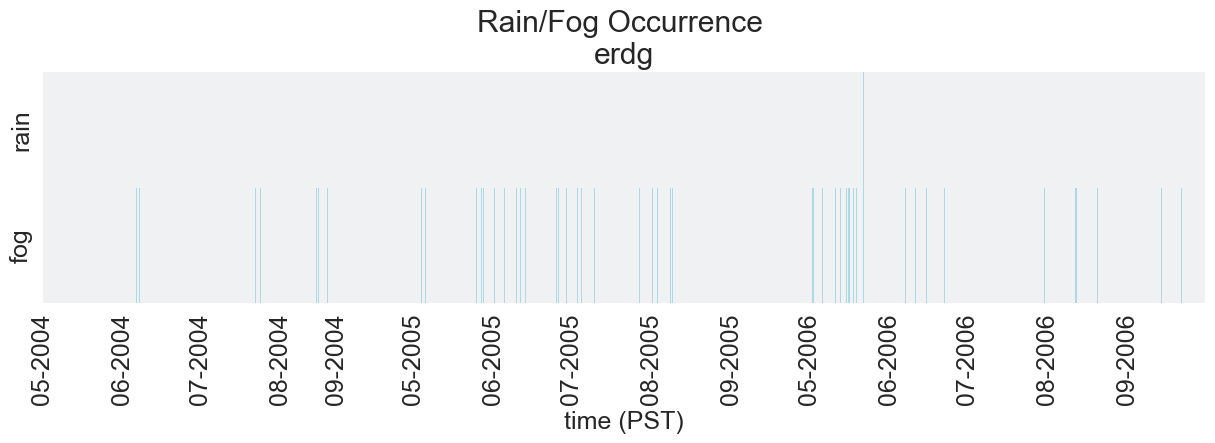

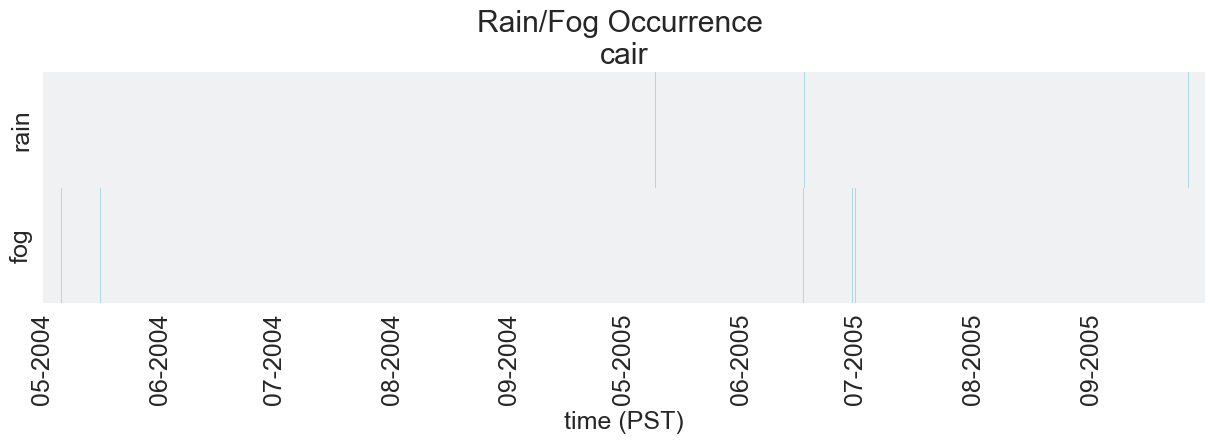

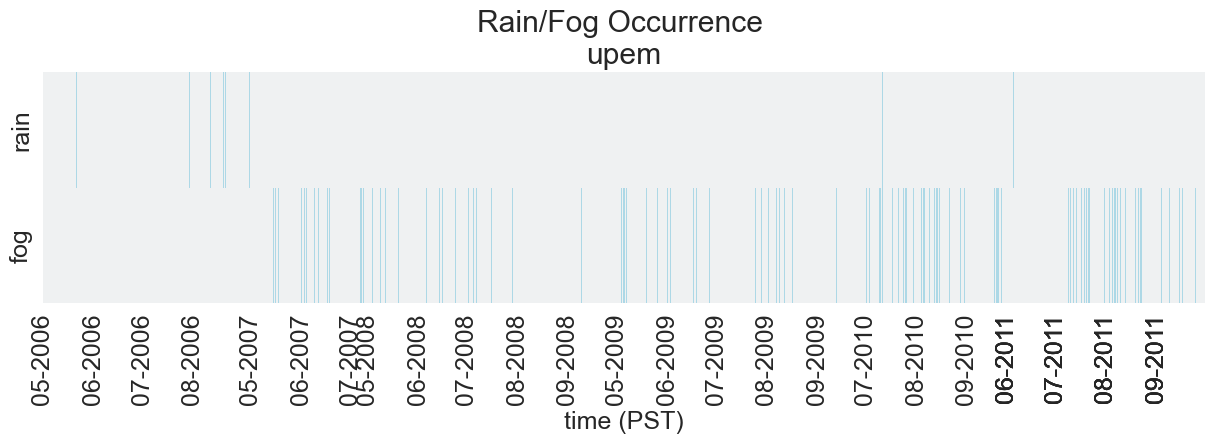

In [71]:
rain_bool = met_df['rain (mm)'].apply(lambda x: 1 if x > 0 else 0)
fog_bool = met_df['fog tips'].apply(lambda x: 1 if x > 0 else 0)
ind = met_df.index

df = pd.DataFrame({'rain' : rain_bool,
                   'fog' : fog_bool},
                   index=ind)

for i, site in enumerate(sites):
    site_df = df.loc[site]
    fig, ax = plt.subplots(figsize=(15,3))
    sns.heatmap(site_df.T, cmap=sns.light_palette('lightblue'), cbar=False, ax=ax)

    # Format x-axis ticks every 12 hours
    time_index = site_df.index
    tick_locs = [i for i, t in enumerate(time_index) if t.day == 1 and t.hour == 0 and t.minute == 0]

    ax.set_xticks(tick_locs)
    ax.set_xticklabels([time_index[i].strftime('%m-%Y') for i in tick_locs], rotation=90)
    ax.set(title=f'Rain/Fog Occurrence \n{site}')
    plt.show()

In [72]:
# Drop duplicated indices
met_df = met_df[~met_df.index.duplicated(keep='first')]

# Write out dataset


In [74]:
# Write out dataset
met_df.to_csv(clean_outfpath)